CRS: EPSG:3857
Width: 5056
Height: 885
Band count: 5
NoData: None
NDVI min: 0.18131465508056882
NDVI max: 0.8922386534092485
Saved masked NDVI raster to:
C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\NDVI_output\6_10_2020_masked_NDVI.tif
Display range: 0.56983 0.86805916


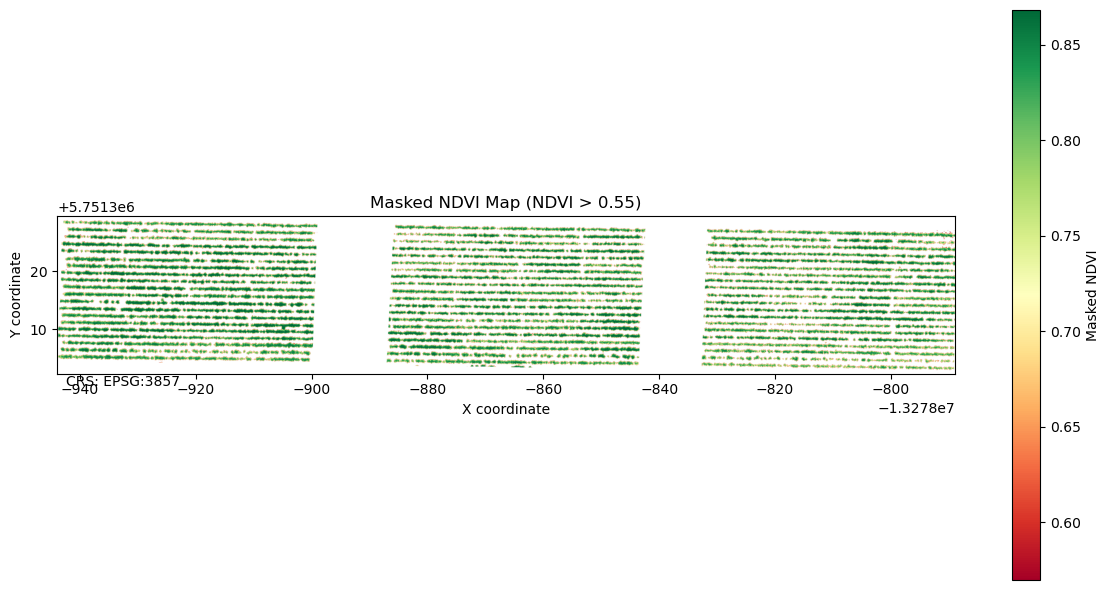

Saved NDVI map to:
C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\NDVI_output\6_10_2020_masked_NDVI_map.png


In [1]:
#    “Copyright (C) 2024 Mississippi State University.
 
#    This program is free software: you can redistribute it and/or modify
#    it under the terms of the GNU General Public License as published by
#    the Free Software Foundation, either version 3 of the License, or
#    (at your option) any later version.
 
#    This program is distributed in the hope that it will be useful,
#    but WITHOUT ANY WARRANTY; without even the implied warranty of
#    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
#    GNU General Public License for more details.
 
#    You should have received a copy of the GNU General Public License
#    along with this program.  If not, see <https://www.gnu.org/licenses/>.
 
# To inquire about relicensing, accessing more training data, collaborating with the author, or any general inquiry about the software, please contact Mississippi State University’s Office of Technology Management at otm@msstate.edu, (662) 325-9263.”


# Dependency Libraries
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import plotting_extent

# INPUT

clipped_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\Shape clip\6_10_2020_clipped_stack.tif"
output_folder = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\NDVI_output"

NDVI_SOIL_THRESHOLD = 0.55

# Create output folder
os.makedirs(output_folder, exist_ok=True)

# Output paths
ndvi_tif_path = os.path.join(output_folder, "6_10_2020_masked_NDVI.tif")
ndvi_png_path = os.path.join(output_folder, "6_10_2020_masked_NDVI_map.png")


# READ IMAGE

with rasterio.open(clipped_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Band count:", src.count)
    print("NoData:", src.nodata)

    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs

    # Stack order: B, G, R, RE, NIR
    r = src.read(3, masked=True).filled(np.nan).astype(np.float64)
    nir = src.read(5, masked=True).filled(np.nan).astype(np.float64)


# VALID MASK

valid_mask = (
    np.isfinite(r) &
    np.isfinite(nir) &
    (np.abs(r) < 1e6) &
    (np.abs(nir) < 1e6)
)


# NDVI COMPUTATION

ndvi = np.full(r.shape, np.nan, dtype=np.float64)

den = nir + r
safe_mask = valid_mask & np.isfinite(den) & (np.abs(den) > 1e-10)

ndvi[safe_mask] = (nir[safe_mask] - r[safe_mask]) / den[safe_mask]

# keep only physical NDVI range
ndvi[(ndvi < -1) | (ndvi > 1)] = np.nan

print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))


# MASK SOIL / NON-VEGETATION

veg_mask = safe_mask & (ndvi > NDVI_SOIL_THRESHOLD)

ndvi_masked = np.full_like(ndvi, np.nan, dtype=np.float32)
ndvi_masked[veg_mask] = ndvi[veg_mask].astype(np.float32)

# SAVE MASKED NDVI AS GEOTIFF

profile.update(
    dtype="float32",
    count=1,
    nodata=np.nan
)

with rasterio.open(ndvi_tif_path, "w", **profile) as dst:
    dst.write(ndvi_masked, 1)

print("Saved masked NDVI raster to:")
print(ndvi_tif_path)


# DYNAMIC COLOR RANGE FROM VALID NDVI VALUES

valid_vals = ndvi_masked[np.isfinite(ndvi_masked)]

if valid_vals.size > 0:
    vmin = np.percentile(valid_vals, 2)
    vmax = np.percentile(valid_vals, 98)
else:
    vmin, vmax = -1, 1

print("Display range:", vmin, vmax)


# SAVE NDVI MAP WITH CRS COORDINATES

cmap_ndvi = plt.cm.RdYlGn.copy()
cmap_ndvi.set_bad(color="white")

extent = plotting_extent(ndvi_masked, transform)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(
    ndvi_masked,
    cmap=cmap_ndvi,
    vmin=vmin,
    vmax=vmax,
    extent=extent,
    origin="upper"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Masked NDVI")

ax.set_title(f"Masked NDVI Map (NDVI > {NDVI_SOIL_THRESHOLD})")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")

# Optional: show CRS in title/footer
ax.text(
    0.01, -0.08,
    f"CRS: {crs}",
    transform=ax.transAxes,
    fontsize=10
)

plt.tight_layout()
plt.savefig(ndvi_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved NDVI map to:")
print(ndvi_png_path)

In [2]:
# INPUT

clipped_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\Shape clip\6_10_2020_clipped_stack.tif"
output_folder = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\Vegetation_Indices_Output"

os.makedirs(output_folder, exist_ok=True)


# USER SETTINGS

NDVI_SOIL_THRESHOLD = 0.6

# Parameters required by some indices
a = 1.0      # soil line slope
b = 0.0      # soil line intercept
x = 0.08     # TSAVI adjustment parameter
L = 0.16     # OSAVI soil brightness correction

EPS = 1e-10  # safe denominator threshold


# HELPERS

def safe_divide(num, den, mask=None):
    """
    Safe division. Works with array or scalar denominator.
    Returns NaN where invalid.
    """
    num = np.asarray(num, dtype=np.float64)
    den = np.asarray(den, dtype=np.float64)

    out = np.full(num.shape, np.nan, dtype=np.float64)

    # scalar denominator case
    if den.ndim == 0:
        valid = np.isfinite(num) & np.isfinite(den) & (abs(den) > EPS)
        if mask is not None:
            valid &= mask
        out[valid] = num[valid] / den
        return out

    # array denominator case
    valid = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > EPS)
    if mask is not None:
        valid &= mask

    out[valid] = num[valid] / den[valid]
    return out

def clamp_invalid(arr, min_val=None, max_val=None):
    """
    Replace non-finite or out-of-range values with NaN.
    """
    arr = arr.astype(np.float64)
    arr[~np.isfinite(arr)] = np.nan

    if min_val is not None:
        arr[arr < min_val] = np.nan
    if max_val is not None:
        arr[arr > max_val] = np.nan

    return arr

def save_index_raster(index_array, profile, out_path):
    prof = profile.copy()
    prof.update(dtype="float32", count=1, nodata=np.nan)

    with rasterio.open(out_path, "w", **prof) as dst:
        dst.write(index_array.astype(np.float32), 1)

def save_index_map(index_array, transform, crs, out_png, title, cmap="RdYlGn"):
    cmap_obj = plt.cm.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="white")

    vals = index_array[np.isfinite(index_array)]
    if vals.size > 0:
        vmin = np.percentile(vals, 2)
        vmax = np.percentile(vals, 98)
        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
            vmin = np.nanmin(vals)
            vmax = np.nanmax(vals)
    else:
        vmin, vmax = 0, 1

    extent = plotting_extent(index_array, transform)

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(
        index_array,
        cmap=cmap_obj,
        vmin=vmin,
        vmax=vmax,
        extent=extent,
        origin="upper"
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(title)

    ax.set_title(title)
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.text(0.01, -0.08, f"CRS: {crs}", transform=ax.transAxes, fontsize=10)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)


# READ IMAGE

with rasterio.open(clipped_path) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Band count:", src.count)
    print("NoData:", src.nodata)

    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs

    # Stack order: B, G, R, RE, NIR
    blue    = src.read(1, masked=True).filled(np.nan).astype(np.float64)
    green   = src.read(2, masked=True).filled(np.nan).astype(np.float64)
    red     = src.read(3, masked=True).filled(np.nan).astype(np.float64)
    rededge = src.read(4, masked=True).filled(np.nan).astype(np.float64)
    nir     = src.read(5, masked=True).filled(np.nan).astype(np.float64)


# GLOBAL VALID MASK

base_valid = (
    np.isfinite(blue) &
    np.isfinite(green) &
    np.isfinite(red) &
    np.isfinite(rededge) &
    np.isfinite(nir) &
    (np.abs(blue) < 1e6) &
    (np.abs(green) < 1e6) &
    (np.abs(red) < 1e6) &
    (np.abs(rededge) < 1e6) &
    (np.abs(nir) < 1e6)
)


# NDVI FOR SOIL DETECTION

ndvi_den = nir + red
ndvi = safe_divide(nir - red, ndvi_den, mask=base_valid)
ndvi = clamp_invalid(ndvi, min_val=-1, max_val=1)

print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))

# Soil removal mask
veg_mask = np.isfinite(ndvi) & (ndvi > NDVI_SOIL_THRESHOLD)

# Save masked NDVI first
ndvi_masked = np.full_like(ndvi, np.nan, dtype=np.float64)
ndvi_masked[veg_mask] = ndvi[veg_mask]

save_index_raster(
    ndvi_masked,
    profile,
    os.path.join(output_folder, "masked_ndvi.tif")
)

save_index_map(
    ndvi_masked,
    transform,
    crs,
    os.path.join(output_folder, "masked_ndvi_map.png"),
    f"Masked NDVI (NDVI > {NDVI_SOIL_THRESHOLD})"
)


# COMPUTE ALL REQUESTED INDICES ONLY ON VEGETATION PIXELS

indices = {}

# GNDVI
indices["masked_gndvi"] = safe_divide(nir - green, nir + green, mask=veg_mask)

# DVI
dvi = np.full_like(nir, np.nan, dtype=np.float64)
dvi[veg_mask] = nir[veg_mask] - red[veg_mask]
indices["masked_dvi"] = dvi

# EVI
indices["masked_evi"] = safe_divide(
    2.5 * (nir - red),
    (nir + (6 * red) - (7.5 * blue) + 1.0),
    mask=veg_mask
)

# EVI2
indices["masked_evi2"] = safe_divide(
    2.5 * (nir - red),
    (nir + (2.4 * red) + 1.0),
    mask=veg_mask
)

# MARI
indices["masked_mari"] = np.full_like(nir, np.nan, dtype=np.float64)
valid_mari = veg_mask & np.isfinite(green) & np.isfinite(rededge) & np.isfinite(nir) & (np.abs(green) > EPS) & (np.abs(rededge) > EPS)
indices["masked_mari"][valid_mari] = (((1.0 / green[valid_mari]) - (1.0 / rededge[valid_mari])) * nir[valid_mari])

# CHLRE
indices["masked_chlre"] = safe_divide(nir, rededge, mask=veg_mask) - 1.0

# CHLGR
indices["masked_chlgr"] = safe_divide(nir, green, mask=veg_mask) - 1.0

# SAVI
indices["masked_savi"] = safe_divide(
    1.5 * (nir - red),
    (nir + red + 0.5),
    mask=veg_mask
)

# SAVI2 (using your formula)
indices["masked_savi2"] = safe_divide(
    nir,
    (red + (b / a)),
    mask=veg_mask
)

# MSAVI
msavi = np.full_like(nir, np.nan, dtype=np.float64)
term = ((2 * nir) + 1) ** 2 - (8 * (nir - red))
valid_msavi = veg_mask & np.isfinite(term) & (term >= 0)
msavi[valid_msavi] = (((2 * nir[valid_msavi]) + 1) - np.sqrt(term[valid_msavi])) / 2.0
indices["masked_msavi"] = msavi

# OSAVI (using your formula with green exactly as you wrote)
indices["masked_osavi"] = safe_divide(
    (1 + L) * (nir - green),
    (nir + green + L),
    mask=veg_mask
)

# TSAVI
indices["masked_tsavi"] = safe_divide(
    a * (nir - (a * red) - b),
    ((a * nir) + red - (a * b) + (x * (1 + a**2))),
    mask=veg_mask
)

# MSR
msr_ratio = safe_divide(nir, red, mask=veg_mask)
msr = np.full_like(msr_ratio, np.nan, dtype=np.float64)
valid_msr = np.isfinite(msr_ratio) & ((msr_ratio - 1) > 0)
msr[valid_msr] = (msr_ratio[valid_msr] - 1) / np.sqrt(msr_ratio[valid_msr] - 1)
indices["masked_msr"] = msr

# MCARI
mcari = np.full_like(nir, np.nan, dtype=np.float64)
valid_mcari = veg_mask & np.isfinite(rededge) & np.isfinite(red) & np.isfinite(green) & (np.abs(red) > EPS)
mcari[valid_mcari] = ((rededge[valid_mcari] - red[valid_mcari]) - 0.2 * (rededge[valid_mcari] - green[valid_mcari])) * (rededge[valid_mcari] / red[valid_mcari])
indices["masked_mcari"] = mcari

# MCARI/OSAVI
indices["masked_mcaridiosavi"] = safe_divide(
    indices["masked_mcari"],
    indices["masked_osavi"],
    mask=np.isfinite(indices["masked_mcari"]) & np.isfinite(indices["masked_osavi"])
)

# PVI
indices["masked_pvi"] = safe_divide(
    nir - (a * red) - b,
    np.sqrt(1 + a**2),
    mask=veg_mask
)

# SR
indices["masked_sr"] = safe_divide(nir, red, mask=veg_mask)

# WDRI
indices["masked_wdri"] = safe_divide(
    0.3 * (nir - red),
    0.3 * (nir + red),
    mask=veg_mask
)


# OPTIONAL: CLAMP SOME INDICES IF DESIRED

indices["masked_gndvi"] = clamp_invalid(indices["masked_gndvi"], min_val=-1, max_val=1)
indices["masked_evi"]   = clamp_invalid(indices["masked_evi"],   min_val=-5, max_val=5)
indices["masked_evi2"]  = clamp_invalid(indices["masked_evi2"],  min_val=-5, max_val=5)
indices["masked_savi"]  = clamp_invalid(indices["masked_savi"],  min_val=-1, max_val=2)
indices["masked_msavi"] = clamp_invalid(indices["masked_msavi"], min_val=-1, max_val=2)
indices["masked_osavi"] = clamp_invalid(indices["masked_osavi"], min_val=-2, max_val=2)
indices["masked_wdri"]  = clamp_invalid(indices["masked_wdri"],  min_val=-1, max_val=1)


# SAVE ALL INDICES

for name, arr in indices.items():
    tif_path = os.path.join(output_folder, f"{name}.tif")
    png_path = os.path.join(output_folder, f"{name}_map.png")

    save_index_raster(arr.astype(np.float32), profile, tif_path)
    save_index_map(arr, transform, crs, png_path, title=name)

    vals = arr[np.isfinite(arr)]
    if vals.size > 0:
        print(f"{name}: min={np.nanmin(vals):.4f}, max={np.nanmax(vals):.4f}")
    else:
        print(f"{name}: no valid pixels")

print("\nAll vegetation indices saved to:")
print(output_folder)

CRS: EPSG:3857
Width: 5056
Height: 885
Band count: 5
NoData: None
NDVI min: 0.18131465508056882
NDVI max: 0.8922386534092485


C:\Users\Say70\AppData\Local\Temp\ipykernel_52700\132007508.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()


masked_gndvi: min=0.6611, max=0.8932
masked_dvi: min=0.0684, max=0.6356
masked_evi: min=0.1504, max=1.0527
masked_evi2: min=0.1494, max=0.8909
masked_mari: min=3.1478, max=14.1993
masked_chlre: min=0.4445, max=2.5274
masked_chlgr: min=3.9014, max=16.7267
masked_savi: min=0.1674, max=0.7803
masked_savi2: min=4.0000, max=17.5595
masked_msavi: min=0.1301, max=0.8384
masked_osavi: min=0.3495, max=0.8231
masked_tsavi: min=0.2507, max=0.7231
masked_msr: min=1.7321, max=4.0693
masked_mcari: min=0.0160, max=1.2909
masked_mcaridiosavi: min=0.0390, max=1.6643
masked_pvi: min=0.0483, max=0.4494
masked_sr: min=4.0000, max=17.5595
masked_wdri: min=0.6000, max=0.8922

All vegetation indices saved to:
C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\6_10_2020\Vegetation_Indices_Output
